## Squeeze and Excitation UNET

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from tqdm import tqdm
import json
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.style.use('dark_background')
print("Using device : ",device)

Using device :  cuda


In [2]:
# Paths
NOTEBOOK_DIR = Path().resolve()
BASE_DIR = NOTEBOOK_DIR.parents[1]
SEG_DATASET_DIR = BASE_DIR / "data" / "kvasir-seg" / "Kvasir-SEG"
INPUT_DIR = SEG_DATASET_DIR / "images"
TARGET_DIR = SEG_DATASET_DIR / "masks"
MODEL_OUTPUT_DIR = BASE_DIR / "models" / NOTEBOOK_DIR.name
MODEL_OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
HEIGHT , WIDTH = 512 , 512
IMAGE_SIZE = (HEIGHT , WIDTH)
import sys
sys.path.append(str(BASE_DIR))
import helper

In [3]:
class SegmentationDataset(Dataset):
    """Simple segmentation dataset for image-mask pairs"""
    
    def __init__(self, image_dir, mask_dir, transform=None, img_size=(512,512)):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.img_size = img_size
        
        # Get all image files
        valid_exts = {".jpg", ".jpeg", ".png"}
        self.images = sorted([f for f in self.image_dir.iterdir() if f.suffix.lower() in valid_exts])
        self.masks = sorted([f for f in self.mask_dir.iterdir() if f.suffix.lower() in valid_exts])
        
        assert len(self.images) == len(self.masks), "Images and masks count mismatch!"
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Load image and mask
        img = Image.open(self.images[idx]).convert('RGB')
        mask = Image.open(self.masks[idx]).convert('L')  # Grayscale
        
        # Resize
        img = img.resize(self.img_size, Image.BILINEAR)
        mask = mask.resize(self.img_size, Image.NEAREST)
        
        # Convert to numpy
        img = np.array(img).astype(np.float32) / 255.0
        mask = np.array(mask).astype(np.float32) / 255.0
        
        # To tensor (C, H, W)
        img = torch.from_numpy(img).permute(2, 0, 1)
        mask = torch.from_numpy(mask).unsqueeze(0)  # Add channel dim
        
        return img, mask

In [4]:
# Create datasets
train_dataset = SegmentationDataset(INPUT_DIR, TARGET_DIR, img_size=IMAGE_SIZE)
BATCH_SIZE = 16
# Split into train/val (80/20)
train_size = int(0.65 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")


Train samples: 650, Val samples: 350


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SqueezeExciteBlock(nn.Module):
    """Squeeze-and-Excitation block for channel-wise attention"""
    def __init__(self, channels, reduction=16):
        super(SqueezeExciteBlock, self).__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        # Squeeze: Global average pooling
        y = self.squeeze(x).view(b, c)
        # Excitation: FC layers
        y = self.excitation(y).view(b, c, 1, 1)
        # Scale
        return x * y.expand_as(x)


class DoubleConvSE(nn.Module):
    """Double convolution block with Squeeze-and-Excitation"""
    def __init__(self, in_channels, out_channels):
        super(DoubleConvSE, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.se = SqueezeExciteBlock(out_channels)
    
    def forward(self, x):
        x = self.conv(x)
        x = self.se(x)
        return x


class DownBlock(nn.Module):
    """Downsampling block with double conv and SE"""
    def __init__(self, in_channels, out_channels):
        super(DownBlock, self).__init__()
        self.conv = DoubleConvSE(in_channels, out_channels)
        self.pool = nn.MaxPool2d(2)
    
    def forward(self, x):
        skip = self.conv(x)
        x = self.pool(skip)
        return x, skip


class UpBlock(nn.Module):
    """Upsampling block with double conv and SE"""
    def __init__(self, in_channels, out_channels):
        super(UpBlock, self).__init__()
        # Upsample reduces channels by half
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        # After concatenation: in_channels//2 (upsampled) + in_channels//2 (skip) = in_channels
        # So we need to convolve from in_channels to out_channels
        self.conv = DoubleConvSE(in_channels, out_channels)
    
    def forward(self, x, skip):
        x = self.up(x)
        # Handle size mismatch
        diffY = skip.size()[2] - x.size()[2]
        diffX = skip.size()[3] - x.size()[3]
        x = F.pad(x, [diffX // 2, diffX - diffX // 2,
                      diffY // 2, diffY - diffY // 2])
        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x


class UNetSE(nn.Module):
    """U-Net with Squeeze-and-Excitation blocks
    
    Args:
        in_channels: Number of input channels (default: 3 for RGB images)
        out_channels: Number of output channels (default: 1 for binary segmentation)
        base_filters: Number of filters in the first layer (default: 64)
    """
    def __init__(self, in_channels=3, out_channels=1, base_filters=64):
        super(UNetSE, self).__init__()
        
        # Initial convolution
        self.inc = DoubleConvSE(in_channels, base_filters)
        
        # Encoder (downsampling path)
        self.down1 = DownBlock(base_filters, base_filters * 2)
        self.down2 = DownBlock(base_filters * 2, base_filters * 4)
        self.down3 = DownBlock(base_filters * 4, base_filters * 8)
        
        # Bottleneck
        self.bottleneck = DoubleConvSE(base_filters * 8, base_filters * 16)
        
        # Decoder (upsampling path)
        # Each UpBlock takes concatenated channels and reduces to output channels
        self.up1 = UpBlock(base_filters * 16, base_filters * 8)
        self.up2 = UpBlock(base_filters * 8, base_filters * 4)
        self.up3 = UpBlock(base_filters * 4, base_filters * 2)
        self.up4 = UpBlock(base_filters * 2, base_filters)
        
        # Output convolution
        self.outc = nn.Conv2d(base_filters, out_channels, kernel_size=1)
    
    def forward(self, x):
        # Initial convolution
        x1 = self.inc(x)
        
        # Encoder with skip connections
        x2, skip1 = self.down1(x1)  # skip1: base_filters*2
        x3, skip2 = self.down2(x2)  # skip2: base_filters*4
        x4, skip3 = self.down3(x3)  # skip3: base_filters*8
        
        # Bottleneck
        x5 = self.bottleneck(x4)  # base_filters*16
        
        # Decoder with skip connections
        x = self.up1(x5, skip3)  # base_filters*16 -> base_filters*8
        x = self.up2(x, skip2)   # base_filters*8 -> base_filters*4
        x = self.up3(x, skip1)   # base_filters*4 -> base_filters*2
        x = self.up4(x, x1)      # base_filters*2 -> base_filters
        
        # Output
        logits = self.outc(x)
        return logits

In [6]:
class DiceLoss(nn.Module):
    """Dice Loss for segmentation"""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        
    def forward(self, pred, target):
        pred = pred.contiguous().view(-1)
        target = target.contiguous().view(-1)
        
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        
        return 1 - dice


class CombinedLoss(nn.Module):
    """Combines Dice Loss and BCE"""
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCELoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        
    def forward(self, pred, target):
        return self.dice_weight * self.dice(pred, target) + self.bce_weight * self.bce(pred, target)
    
def calculate_iou(pred, target, threshold=0.5):
    """Calculate IoU metric"""
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()


In [7]:
# Model, loss, optimizer
model = UNetSE(in_channels=3, out_channels=1, base_filters=2)
model = model.to(device)
criterion = CombinedLoss(dice_weight=0.5, bce_weight=0.5)
dice_criterion = DiceLoss()
bce_criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
# Inspect model architecture
helper.inspect_model(
    model, 
    input_size=(1,3,HEIGHT,WIDTH),
    criterion=criterion,
    optimizer=optimizer,
    model_name="U-Net with Residual Connections"
)

c:\Users\SriRam.A\miniconda3\envs\pytorch-miniconda\Lib\site-packages\torch\nn\init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


───────────────────────────────────────── U-Net with Residual Connections ─────────────────────────────────────────

Architecture Summary:

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
UNetSE                                        [1, 3, 512, 512]          [1, 1, 512, 512]          --
├─DoubleConvSE: 1-1                           [1, 3, 512, 512]          [1, 2, 512, 512]          --
│    └─Sequential: 2-1                        [1, 3, 512, 512]          [1, 2, 512, 512]          --
│    │    └─Conv2d: 3-1                       [1, 3, 512, 512]          [1, 2, 512, 512]          54
│    │    └─BatchNorm2d: 3-2                  [1, 2, 512, 512]          [1, 2, 512, 512]          4
│    │    └─ReLU: 3-3                         [1, 2, 512, 512]          [1, 2, 512, 512]          --
│    │    └─Conv2d: 3-4                       [1, 2, 512, 512]          [1, 2, 512, 512]          36
│    │    └─BatchNorm2d: 3-5                  [1, 2, 512, 512]          [1, 2, 512, 512]          4
│    │    └─ReLU: 3-6                         [1, 2, 512, 512]          [1, 2, 512, 512]

MACs and Parameters (ptflops):

╷               
  Metric               │        Value  
 ══════════════════════╪══════════════ 
  Total Parameters     │       30,943  
  Trainable Parameters │       30,943  
  Optimizer Params     │       30,943  
  Model Size (MB)      │        0.118  
  MACs                 │  809.24 MMac  
  FLOPs (approx)       │  809.24 MMac  
  Loss Function        │ CombinedLoss  
  Optimizer            │         Adam  
                       ╵

In [8]:
dice_weight , bce_weight = 0.5 , 0.5

def train_epoch(model, loader, dice_criterion, bce_criterion, optimizer, device):
    model.train()
    total_loss = 0
    total_dice_loss = 0
    total_bce_loss = 0
    total_iou = 0
    
    for imgs, masks in tqdm(loader, desc="Training", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        
        # Calculate both losses
        dice_loss = dice_criterion(outputs, masks)
        bce_loss = bce_criterion(outputs, masks)
        loss = dice_weight*dice_loss + bce_weight*bce_loss  # Combined loss
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_dice_loss += dice_loss.item()
        total_bce_loss += bce_loss.item()
        total_iou += calculate_iou(outputs, masks)
    
    n = len(loader)
    return total_loss / n, total_dice_loss / n, total_bce_loss / n, total_iou / n

def validate(model, loader, dice_criterion, bce_criterion, device):
    model.eval()
    total_loss = 0
    total_dice_loss = 0
    total_bce_loss = 0
    total_iou = 0
    
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Validation", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            
            outputs = model(imgs)
            
            # Calculate both losses
            dice_loss = dice_criterion(outputs, masks)
            bce_loss = bce_criterion(outputs, masks)
            loss = dice_weight*dice_loss + bce_weight*bce_loss
            
            total_loss += loss.item()
            total_dice_loss += dice_loss.item()
            total_bce_loss += bce_loss.item()
            total_iou += calculate_iou(outputs, masks)
    
    n = len(loader)
    return total_loss / n, total_dice_loss / n, total_bce_loss / n, total_iou / n


In [9]:
history = {
    'train_loss': [], 'train_dice': [], 'train_bce': [], 'train_iou': [],
    'val_loss': [], 'val_dice': [], 'val_bce': [], 'val_iou': []
}
best_val_loss = float('inf')

In [10]:
# Training with detailed loss tracking
epochs = 50

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    train_loss, train_dice, train_bce, train_iou = train_epoch(
        model, train_loader, dice_criterion, bce_criterion, optimizer, device
    )
    val_loss, val_dice, val_bce, val_iou = validate(
        model, val_loader, dice_criterion, bce_criterion, device
    )
    # Store history
    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['train_bce'].append(train_bce)
    history['train_iou'].append(train_iou)
    
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_bce'].append(val_bce)
    history['val_iou'].append(val_iou)
    
    scheduler.step(val_loss)
    
    # Print detailed metrics
    print(f"TRAIN → Total: {train_loss:.4f} | Dice: {train_dice:.4f} | BCE: {train_bce:.4f} | IoU: {train_iou:.4f}")
    print(f"VAL   → Total: {val_loss:.4f} | Dice: {val_dice:.4f} | BCE: {val_bce:.4f} | IoU: {val_iou:.4f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_OUTPUT_DIR / f"best_unet_model.pth")
        print("✓ Best model saved!")

Epoch 1/50


TRAIN → Total: 1.4354 | Dice: 2.2335 | BCE: 0.6374 | IoU: 0.0055
VAL   → Total: 2.2711 | Dice: 3.8979 | BCE: 0.6443 | IoU: 0.0020
✓ Best model saved!
Epoch 2/50


TRAIN → Total: 31.8736 | Dice: 63.1053 | BCE: 0.6418 | IoU: 0.0062
VAL   → Total: 3.7002 | Dice: 6.7582 | BCE: 0.6422 | IoU: 0.0071
Epoch 3/50


TRAIN → Total: 0.5227 | Dice: 0.4003 | BCE: 0.6451 | IoU: 0.0072
VAL   → Total: 0.8830 | Dice: 1.1227 | BCE: 0.6434 | IoU: 0.0068
✓ Best model saved!
Epoch 4/50


TRAIN → Total: -2.4978 | Dice: -5.6409 | BCE: 0.6452 | IoU: 0.0074
VAL   → Total: -0.6300 | Dice: -1.9037 | BCE: 0.6438 | IoU: 0.0072
✓ Best model saved!
Epoch 5/50


...

TRAIN → Total: -8.6496 | Dice: -17.9467 | BCE: 0.6475 | IoU: 0.0076
VAL   → Total: 1.2303 | Dice: 1.8146 | BCE: 0.6459 | IoU: 0.0073
Epoch 47/50


TRAIN → Total: -4.1602 | Dice: -8.9679 | BCE: 0.6476 | IoU: 0.0075
VAL   → Total: 1.1676 | Dice: 1.6892 | BCE: 0.6460 | IoU: 0.0072
Epoch 48/50


TRAIN → Total: 1.1390 | Dice: 1.6304 | BCE: 0.6476 | IoU: 0.0075
VAL   → Total: 1.3583 | Dice: 2.0709 | BCE: 0.6458 | IoU: 0.0071
Epoch 49/50


TRAIN → Total: 5.2992 | Dice: 9.9508 | BCE: 0.6476 | IoU: 0.0076
VAL   → Total: 1.1529 | Dice: 1.6598 | BCE: 0.6460 | IoU: 0.0074
Epoch 50/50


TRAIN → Total: 1.7207 | Dice: 2.7938 | BCE: 0.6476 | IoU: 0.0076
VAL   → Total: 1.2768 | Dice: 1.9077 | BCE: 0.6458 | IoU: 0.0074


In [12]:
! ipynb-py-convert 1-main.ipynb 1-main.py

In [11]:
        
print("TRAINING SUMMARY")
print(f"Best Validation Loss:      {min(history['val_loss']):.4f} (Epoch {np.argmin(history['val_loss'])+1})")
print(f"Best Validation IoU:       {max(history['val_iou']):.4f} (Epoch {np.argmax(history['val_iou'])+1})")
print(f"Final Train Loss:          {history['train_loss'][-1]:.4f}")
print(f"  ├─ Dice Loss:            {history['train_dice'][-1]:.4f}")
print(f"  └─ BCE Loss:             {history['train_bce'][-1]:.4f}")
print(f"Final Validation Loss:     {history['val_loss'][-1]:.4f}")
print(f"  |─ Dice Loss:            {history['val_dice'][-1]:.4f}")
print(f"  └─ BCE Loss:             {history['val_bce'][-1]:.4f}")


TRAINING SUMMARY
Best Validation Loss:      -2.2030 (Epoch 12)
Best Validation IoU:       0.0078 (Epoch 15)
Final Train Loss:          1.7207
  ├─ Dice Loss:            2.7938
  └─ BCE Loss:             0.6476
Final Validation Loss:     1.2768
  |─ Dice Loss:            1.9077
  └─ BCE Loss:             0.6458


In [12]:
# Save final model in multiple formats
torch.save(model.state_dict(), MODEL_OUTPUT_DIR / "final_unet_model_state_dict.pth")
torch.save(model, MODEL_OUTPUT_DIR / "final_unet_model_complete.pth")
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history
}, MODEL_OUTPUT_DIR / "checkpoint.pth")

print("\n✓ All models saved!")


✓ All models saved!


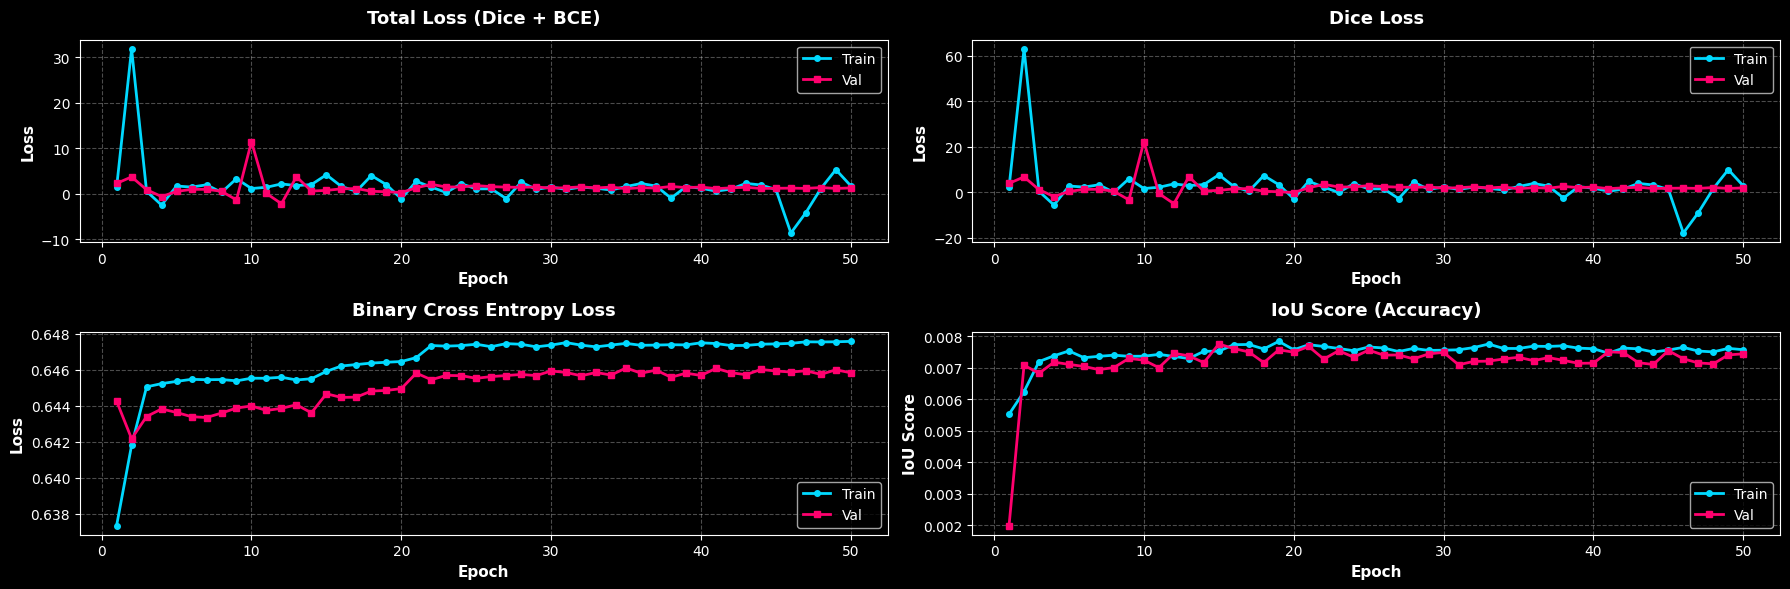

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 6))

epochs_range = range(1, len(history['train_loss']) + 1)

# Total Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'o-', color='#00d9ff', linewidth=2, label='Train', markersize=4)
axes[0, 0].plot(epochs_range, history['val_loss'], 's-', color='#ff006e', linewidth=2, label='Val', markersize=4)
axes[0, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Loss', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Total Loss (Dice + BCE)', fontsize=13, fontweight='bold', pad=12)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3, linestyle='--')

# Dice Loss
axes[0, 1].plot(epochs_range, history['train_dice'], 'o-', color='#00d9ff', linewidth=2, label='Train', markersize=4)
axes[0, 1].plot(epochs_range, history['val_dice'], 's-', color='#ff006e', linewidth=2, label='Val', markersize=4)
axes[0, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Loss', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Dice Loss', fontsize=13, fontweight='bold', pad=12)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3, linestyle='--')

# BCE Loss
axes[1, 0].plot(epochs_range, history['train_bce'], 'o-', color='#00d9ff', linewidth=2, label='Train', markersize=4)
axes[1, 0].plot(epochs_range, history['val_bce'], 's-', color='#ff006e', linewidth=2, label='Val', markersize=4)
axes[1, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Loss', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Binary Cross Entropy Loss', fontsize=13, fontweight='bold', pad=12)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3, linestyle='--')

# IoU (Accuracy)
axes[1, 1].plot(epochs_range, history['train_iou'], 'o-', color='#00d9ff', linewidth=2, label='Train', markersize=4)
axes[1, 1].plot(epochs_range, history['val_iou'], 's-', color='#ff006e', linewidth=2, label='Val', markersize=4)
axes[1, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('IoU Score', fontsize=11, fontweight='bold')
axes[1, 1].set_title('IoU Score (Accuracy)', fontsize=13, fontweight='bold', pad=12)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / 'training_history_detailed.png', dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

In [14]:
import cv2
import numpy as np

def create_overlay(rgb_img, mask, pred_mask=None, alpha=0.4):
    """Overlay where overlap is green and mismatched areas are red."""
    rgb_img = (rgb_img * 255).astype(np.uint8) if rgb_img.max() <= 1 else rgb_img.astype(np.uint8)
    if pred_mask is None:
        # Simple overlay with true mask
        overlay = rgb_img.copy()
        mask_colored = np.zeros_like(rgb_img)
        mask_colored[:, :, 1] = (mask * 255).astype(np.uint8)  # Green channel
        return cv2.addWeighted(rgb_img, 1-alpha, mask_colored, alpha, 0)
    # Binarize masks
    mask_bin = (mask > 0.5).astype(np.uint8)
    pred_bin = (pred_mask > 0.5).astype(np.uint8)
    
    overlay = rgb_img.copy()
    color_layer = np.zeros_like(rgb_img)

    # Overlap (TP): Green
    tp = (mask_bin & pred_bin)
    color_layer[tp == 1] = (0, 255, 0)
    
    # Non-overlapping (errors): Red
    error = (mask_bin ^ pred_bin)  # XOR = non-overlapping
    color_layer[error == 1] = (255, 0, 0)

    # Blend with original image
    overlay = cv2.addWeighted(rgb_img, 1 - alpha, color_layer, alpha, 0)

    return overlay




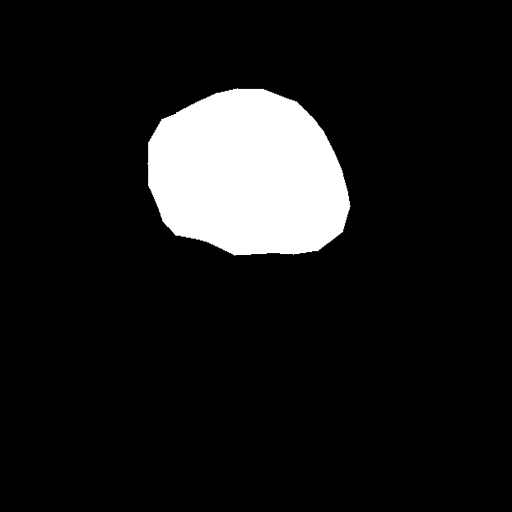
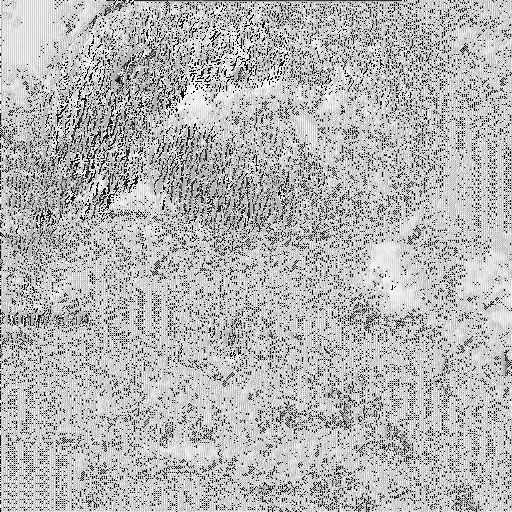
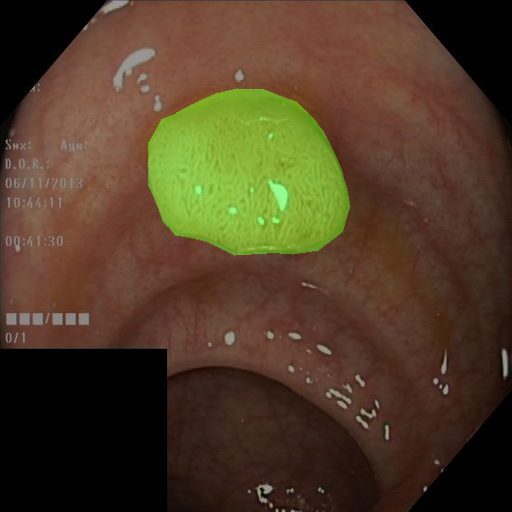
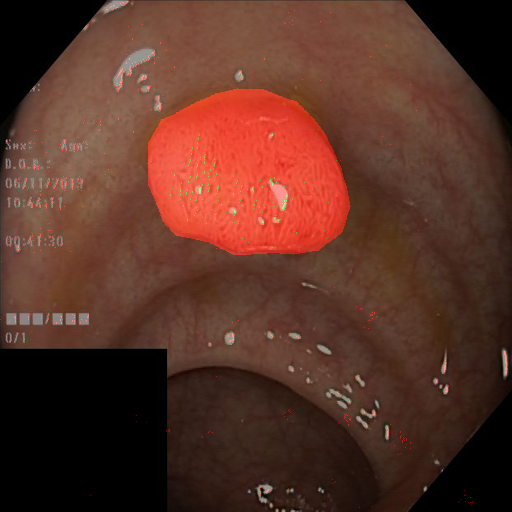

In [16]:
# # Load best model
# model.load_state_dict(torch.load(MODEL_OUTPUT_DIR / "best_unet_model.pth"))
model.eval()
# Get random images
image_paths = helper.get_images_from_dirs([INPUT_DIR, TARGET_DIR])
# Load and preprocess
img_pil = Image.open(image_paths[0]).convert('RGB')
mask_pil = Image.open(image_paths[1]).convert('L')
img_resized = img_pil.resize((HEIGHT,WIDTH))
img_tensor = torch.from_numpy(np.array(img_resized).astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device)
# Predict
with torch.no_grad():
    pred = model(img_tensor).cpu().numpy()[0, 0]
# Convert for visualization
img_np = np.array(img_resized)
mask_np = np.array(mask_pil.resize((HEIGHT,WIDTH))) / 255.0
# Create overlays
overlay_true = create_overlay(img_np, mask_np)
overlay_pred = create_overlay(img_np, mask_np, pred)
# Display using helper
helper.show_grid({
    # 'RGB Image': img_np,
    'True Mask': (mask_np * 255).astype(np.uint8),
    'Predicted Mask': (pred * 255).astype(np.uint8),
    'RGB + True Mask': overlay_true,
    'RGB + Predicted': overlay_pred
}, grid="row",width=1300)

In [ ]:
def evaluate_validation_set(model, val_image_dir, val_mask_dir, device, img_size=(256, 256), sample_pixels=10000):
    """
    Efficient evaluation with pixel sampling to avoid memory issues
    
    Args:
        sample_pixels: Number of pixels to sample per image for confusion matrix
    """
    model.eval()
    
    val_images = sorted(list(Path(val_image_dir).glob('*.png')) + list(Path(val_image_dir).glob('*.jpg')))
    val_masks = sorted(list(Path(val_mask_dir).glob('*.png')) + list(Path(val_mask_dir).glob('*.jpg')))
    
    # Use limited subset if too many images
    if len(val_images) > 100:
        print(f"Using 100 images for evaluation (out of {len(val_images)})")
        val_images = val_images[:100]
        val_masks = val_masks[:100]
    
    all_preds = []
    all_targets = []
    ious = []
    precisions = []
    recalls = []
    
    with torch.no_grad():
        for img_path, mask_path in tqdm(zip(val_images, val_masks), total=len(val_images), desc="Evaluating"):
            # Load and preprocess
            img = Image.open(img_path).convert('RGB').resize(img_size)
            mask = Image.open(mask_path).convert('L').resize(img_size)
            
            img_tensor = torch.from_numpy(np.array(img).astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device)
            mask_np = np.array(mask) / 255.0
            
            # Predict
            pred = model(img_tensor).cpu().numpy()[0, 0]
            
            # Binary masks
            pred_bin = (pred > 0.5).astype(np.uint8)
            mask_bin = (mask_np > 0.5).astype(np.uint8)
            
            # Sample pixels randomly to avoid memory issues
            h, w = pred_bin.shape
            total_pixels = h * w
            
            if total_pixels > sample_pixels:
                # Random sampling
                indices = np.random.choice(total_pixels, sample_pixels, replace=False)
                pred_flat = pred_bin.flatten()[indices]
                mask_flat = mask_bin.flatten()[indices]
            else:
                pred_flat = pred_bin.flatten()
                mask_flat = mask_bin.flatten()
            
            all_preds.extend(pred_flat)
            all_targets.extend(mask_flat)
            
            # Calculate per-image metrics
            intersection = (pred_bin * mask_bin).sum()
            union = pred_bin.sum() + mask_bin.sum() - intersection
            iou = intersection / (union + 1e-6)
            ious.append(iou)
            
            # Per-image precision and recall
            tp = (pred_bin * mask_bin).sum()
            fp = (pred_bin * (1 - mask_bin)).sum()
            fn = ((1 - pred_bin) * mask_bin).sum()
            
            precision = tp / (tp + fp + 1e-6)
            recall = tp / (tp + fn + 1e-6)
            
            precisions.append(precision)
            recalls.append(recall)
    
    # Convert to numpy for faster computation
    all_preds = np.array(all_preds, dtype=np.uint8)
    all_targets = np.array(all_targets, dtype=np.uint8)
    
    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    precision = np.mean(precisions)
    recall = np.mean(recalls)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-6)
    mean_iou = np.mean(ious)
    
    cm = confusion_matrix(all_targets, all_preds)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'mean_iou': mean_iou,
        'confusion_matrix': cm,
        'n_images': len(val_images)
    }


Evaluating: 100%|██████████| 22/22 [00:05<00:00,  3.88it/s]


Elapsed (s): 10.270281076431274

METRICS ON TRAINING DATASET==================================================
VALIDATION METRICS
Pixel Accuracy:  0.1563
Precision:       0.1563
Recall:          1.0000
F1 Score:        0.2704
Mean IoU:        0.1563


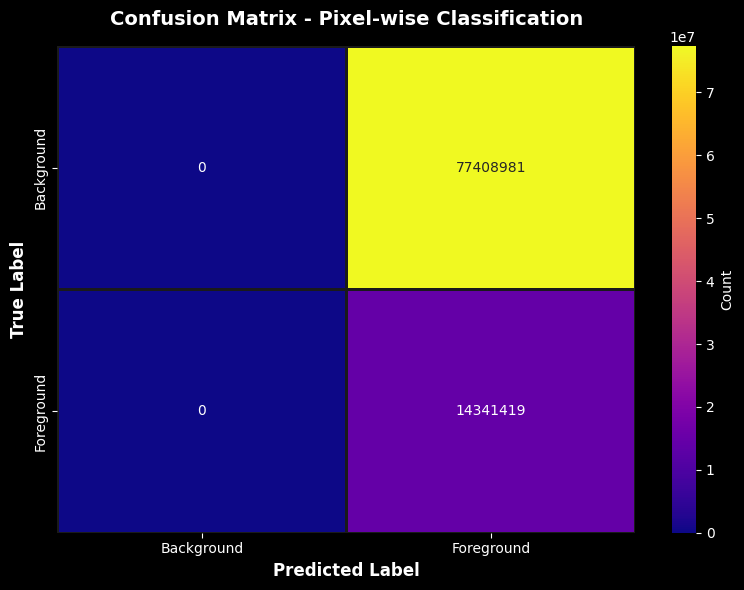

In [ ]:
# Evaluate on validation set
metrics = evaluate_validation_set(model, INPUT_DIR, TARGET_DIR, device)

# Print metrics
print("\nMETRICS ON TRAINING DATASET" + "="*50)
print("VALIDATION METRICS")
print("="*50)
print(f"Pixel Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision:       {metrics['precision']:.4f}")
print(f"Recall:          {metrics['recall']:.4f}")
print(f"F1 Score:        {metrics['f1']:.4f}")
print(f"Mean IoU:        {metrics['mean_iou']:.4f}")
print("="*50)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='plasma', 
            xticklabels=['Background', 'Foreground'], 
            yticklabels=['Background', 'Foreground'],
            cbar_kws={'label': 'Count'},
            ax=ax, linewidths=2, linecolor='#1a1a1a')

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Pixel-wise Classification', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

In [ ]:
VAL_DIR = BASE_DIR / "data" / "kvasir-sessile" / "sessile-main-Kvasir-SEG"
VAL_INPUT_DIR = VAL_DIR / "images"
VAL_MASK_DIR = VAL_DIR / "masks"
# Evaluate on validation set
metrics = evaluate_validation_set(model, VAL_INPUT_DIR, VAL_MASK_DIR, device)

# Print metrics
print("\nMETRICS ON VALIDATION DATASET" + "="*50)
print("VALIDATION METRICS")
print("="*50)
print(f"Pixel Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision:       {metrics['precision']:.4f}")
print(f"Recall:          {metrics['recall']:.4f}")
print(f"F1 Score:        {metrics['f1']:.4f}")
print(f"Mean IoU:        {metrics['mean_iou']:.4f}")
print("="*50)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='plasma', 
            xticklabels=['Background', 'Foreground'], 
            yticklabels=['Background', 'Foreground'],
            cbar_kws={'label': 'Count'},
            ax=ax, linewidths=2, linecolor='#1a1a1a')

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Pixel-wise Classification', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

In [ ]:
# ✅ Best practice method — clean and version-safe.
# import torch
# from your_model_file import UNet  # import your model class
# # Recreate model architecture
# model = UNet()
# # Load weights
# model.load_state_dict(torch.load("final_unet_model_state_dict.pth"))
# model.eval()  # set to evaluation mode

# ⚠️ Note: This method can cause issues if the model’s class definition changed or if loaded in a different environment.
# import torch

# model = torch.load("final_unet_model_complete.pth")
# model.eval()


# You can then resume training or evaluate the model.
# import torch
# from your_model_file import UNet

# model = UNet()
# optimizer = torch.optim.Adam(model.parameters())

# checkpoint = torch.load("checkpoint.pth")

# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# history = checkpoint['history']

# print("Training history:", history.keys())
